# Análise de Interseções LiDAR × Inventário

Este notebook analisa o cruzamento espacial e temporal entre os dados LiDAR (NASA/ORNL) e os inventários florestais de campo.

**Seções:**
1. Interseções geométricas brutas (sem filtro temporal)
2. Melhor match por parcela (LiDAR de ano mais próximo)
3. Distribuição de gaps temporais
4. Variabilidade de área das parcelas
5. Variabilidade de formato das parcelas (compacidade)

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

ROOT = Path("..")
INTERSECTIONS = ROOT / "data/processed/02_intersections/lidar_inventory_intersections.csv"
TEMPORAL_CSV  = ROOT / "data/processed/02_intersections/intersections_temporal.csv"

plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

---
## 1. Interseções geométricas (sem filtro temporal)

Cada parcela de inventário pode aparecer múltiplas vezes — uma vez por campanha LiDAR que a cobre geometricamente (independente do ano).

In [2]:
raw  = pd.read_csv(INTERSECTIONS)
temp = pd.read_csv(TEMPORAL_CSV)

# Extrai nome da campanha LiDAR (sem o número do tile)
temp["campanha_lidar"] = temp["nome_area_lidar"].str.extract(r"^(.+)_\d+\.laz$")[0]
temp["abs_gap"] = temp["gap_temporal_anos"].abs()

n_pairs       = len(raw)
n_plots       = raw.groupby(["inventory_file", "plot_id"]).ngroups
n_inv_sites   = raw["inventory_file"].nunique()
n_lidar_tiles = raw["laz_file"].nunique()

print("=== Interseções geométricas brutas ===")
print(f"  Pares (plot × tile):                    {n_pairs:>5,}")
print(f"  Parcelas únicas com alguma cobertura:   {n_plots:>5,}")
print(f"  Sites de inventário cobertos:           {n_inv_sites:>5,}")
print(f"  Tiles LiDAR utilizados:                 {n_lidar_tiles:>5,}")

=== Interseções geométricas brutas ===
  Pares (plot × tile):                    1,362
  Parcelas únicas com alguma cobertura:     294
  Sites de inventário cobertos:              27
  Tiles LiDAR utilizados:                   252


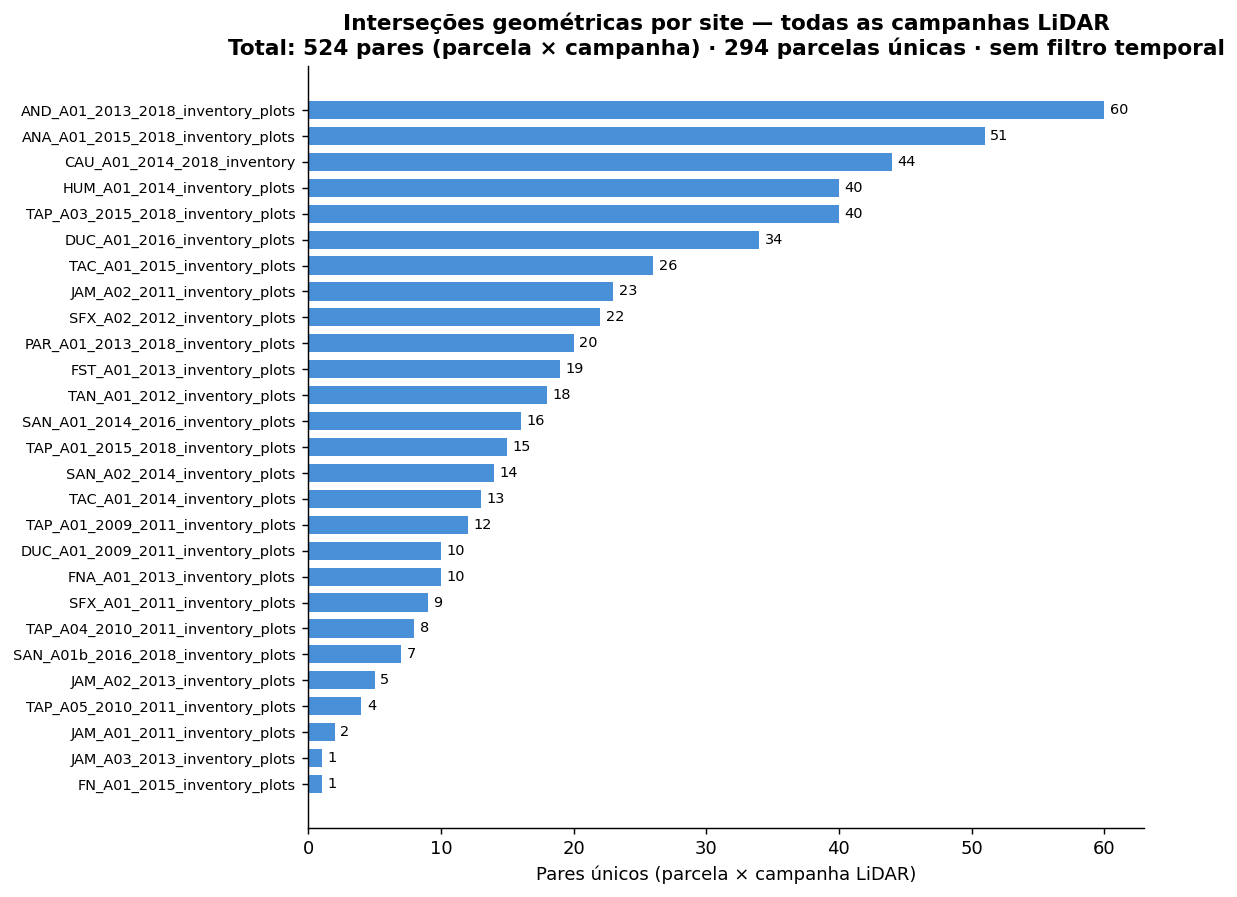

In [3]:
# Pares únicos (parcela × campanha LiDAR) por site de inventário
# Uma parcela aparece N vezes se N campanhas LiDAR diferentes a cobrem
pairs_per_site = (
    temp.groupby(["nome_area_inventario", "plot_id", "campanha_lidar"])
    .size()
    .reset_index()
    .groupby("nome_area_inventario")
    .size()
    .sort_values(ascending=True)
)

total_pairs = pairs_per_site.sum()

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(pairs_per_site.index, pairs_per_site.values, color="#4a90d9", height=0.7)
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_xlabel("Pares únicos (parcela × campanha LiDAR)")
ax.set_title(
    f"Interseções geométricas por site — todas as campanhas LiDAR\n"
    f"Total: {total_pairs} pares (parcela × campanha) · {n_plots} parcelas únicas · sem filtro temporal",
    fontweight="bold"
)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

---
## 2. Melhor match temporal por parcela

Para cada parcela de inventário, seleciona a campanha LiDAR de **ano mais próximo**.  
Resultado: cada parcela aparece exatamente uma vez, pareada com um único LiDAR.

In [4]:
# Melhor campanha por parcela: menor gap absoluto, desempate pelo LiDAR mais recente
best = (
    temp.sort_values(["abs_gap", "ano_lidar"], ascending=[True, False])
    .groupby(["nome_area_inventario", "plot_id"], as_index=False)
    .first()
)

n_best = len(best)
print("=== Melhor match temporal por parcela ===")
print(f"  Parcelas únicas no dataset final:  {n_best:>5,}")
print(f"  Gap = 0 anos (mesmo ano):          {(best.gap_temporal_anos == 0).sum():>5,}")
print(f"  |Gap| ≤ 1 ano:                     {(best.abs_gap <= 1).sum():>5,}")
print(f"  |Gap| ≤ 2 anos:                    {(best.abs_gap <= 2).sum():>5,}")
print(f"  |Gap| > 2 anos:                    {(best.abs_gap  > 2).sum():>5,}")
print()
print(best[["nome_area_inventario", "plot_id", "ano_inventario", "campanha_lidar", "ano_lidar", "gap_temporal_anos"]]
      .head(10).to_string(index=False))

=== Melhor match temporal por parcela ===
  Parcelas únicas no dataset final:    294
  Gap = 0 anos (mesmo ano):            133
  |Gap| ≤ 1 ano:                       213
  |Gap| ≤ 2 anos:                      272
  |Gap| > 2 anos:                       22

             nome_area_inventario plot_id  ano_inventario   campanha_lidar  ano_lidar  gap_temporal_anos
ANA_A01_2015_2018_inventory_plots       1            2015 ANA_A01_2017_laz       2017                  2
ANA_A01_2015_2018_inventory_plots      10            2015 ANA_A01_2017_laz       2017                  2
ANA_A01_2015_2018_inventory_plots      11            2015 ANA_A01_2017_laz       2017                  2
ANA_A01_2015_2018_inventory_plots      12            2015 ANA_A01_2017_laz       2017                  2
ANA_A01_2015_2018_inventory_plots      13            2015 ANA_A01_2018_LAS       2018                  3
ANA_A01_2015_2018_inventory_plots      14            2015 ANA_A01_2018_LAS       2018                  3
ANA_A01

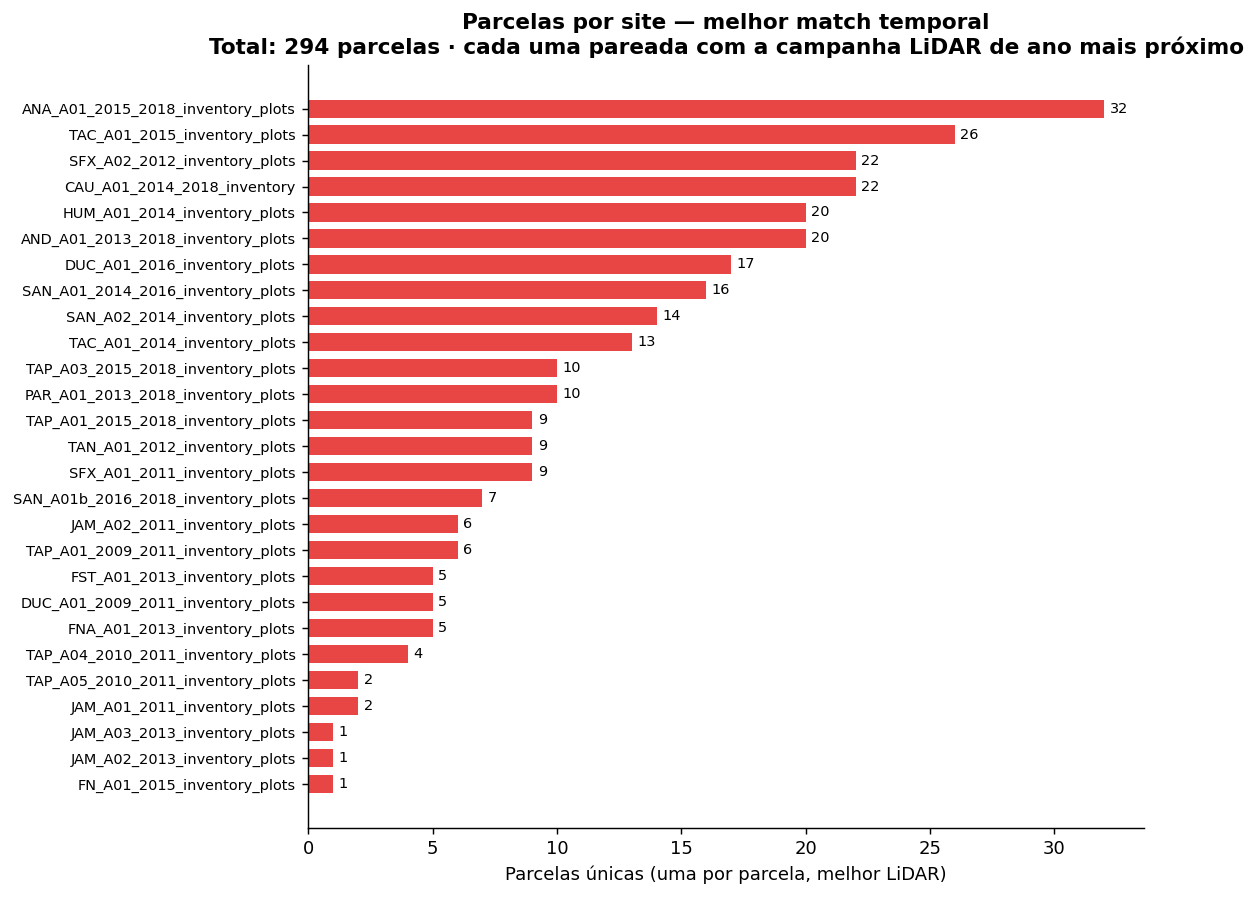

In [5]:
# Parcelas únicas por site após seleção do melhor match
per_site_best = (
    best.groupby("nome_area_inventario")["plot_id"]
    .nunique()
    .sort_values(ascending=True)
)

total_best = per_site_best.sum()

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(per_site_best.index, per_site_best.values, color="#e84545", height=0.7)
ax.bar_label(bars, padding=3, fontsize=8)
ax.set_xlabel("Parcelas únicas (uma por parcela, melhor LiDAR)")
ax.set_title(
    f"Parcelas por site — melhor match temporal\n"
    f"Total: {total_best} parcelas · cada uma pareada com a campanha LiDAR de ano mais próximo",
    fontweight="bold"
)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

---
## 3. Distribuição de gaps temporais

Comparação entre a distribuição bruta (todas as interseções por campanha) e a distribuição no melhor match (uma campanha por parcela).

In [6]:
# Gap no melhor match — agrupado por parcela única
gap_best = (
    best.groupby("gap_temporal_anos")["plot_id"]
    .count()
    .reset_index(name="n_parcelas")
    .sort_values("gap_temporal_anos")
)

# Gap bruto — todos os pares (parcela × campanha), deduplica por campanha
gap_all = (
    temp.drop_duplicates(["nome_area_inventario", "plot_id", "campanha_lidar"])
    .groupby("gap_temporal_anos")
    .size()
    .reset_index(name="n_pares")
    .sort_values("gap_temporal_anos")
)

print("Gap por parcela (melhor match):")
print(gap_best.to_string(index=False))

Gap por parcela (melhor match):
 gap_temporal_anos  n_parcelas
                -3           9
                -2          39
                -1          44
                 0         133
                 1          36
                 2          20
                 3          13


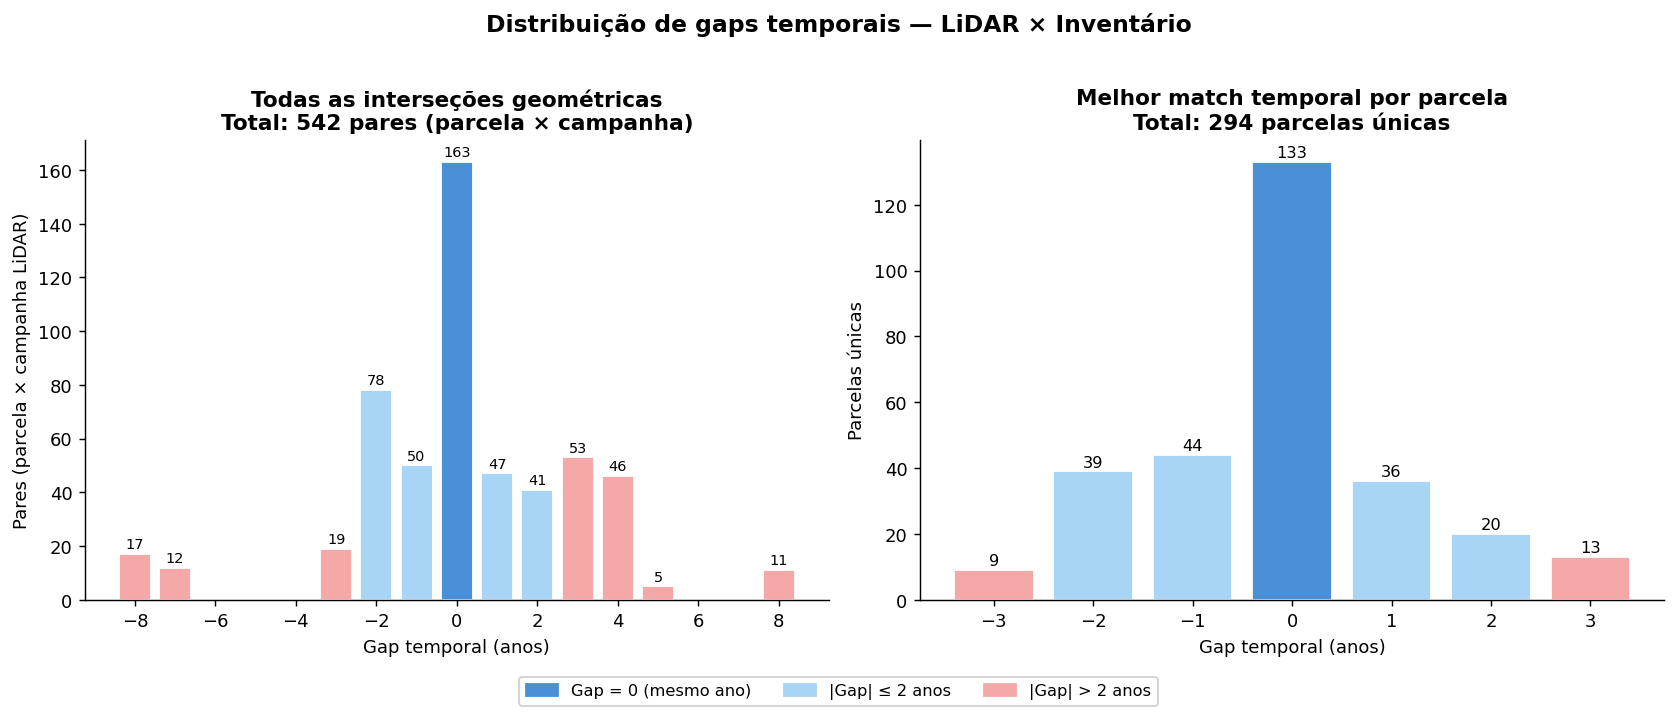

In [7]:
def bar_color(gap, zero_col, near_col, far_col):
    return [zero_col if g == 0 else near_col if abs(g) <= 2 else far_col for g in gap]

COLORS = {"zero": "#4a90d9", "near": "#a8d4f5", "far": "#f5a8a8"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Painel esquerdo: todas as interseções por campanha --
total_all = gap_all["n_pares"].sum()
axes[0].bar(
    gap_all["gap_temporal_anos"], gap_all["n_pares"],
    color=bar_color(gap_all["gap_temporal_anos"], COLORS["zero"], COLORS["near"], COLORS["far"]),
    width=0.8, edgecolor="white"
)
for bar, val in zip(axes[0].patches, gap_all["n_pares"]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 str(val), ha="center", va="bottom", fontsize=8)
axes[0].set_xlabel("Gap temporal (anos)")
axes[0].set_ylabel("Pares (parcela × campanha LiDAR)")
axes[0].set_title(
    f"Todas as interseções geométricas\nTotal: {total_all} pares (parcela × campanha)",
    fontweight="bold"
)
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

# -- Painel direito: melhor match por parcela --
total_bst = gap_best["n_parcelas"].sum()
axes[1].bar(
    gap_best["gap_temporal_anos"], gap_best["n_parcelas"],
    color=bar_color(gap_best["gap_temporal_anos"], COLORS["zero"], COLORS["near"], COLORS["far"]),
    width=0.8, edgecolor="white"
)
for bar, val in zip(axes[1].patches, gap_best["n_parcelas"]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 str(val), ha="center", va="bottom", fontsize=9)
axes[1].set_xlabel("Gap temporal (anos)")
axes[1].set_ylabel("Parcelas únicas")
axes[1].set_title(
    f"Melhor match temporal por parcela\nTotal: {total_bst} parcelas únicas",
    fontweight="bold"
)
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

from matplotlib.patches import Patch
fig.legend(
    handles=[
        Patch(color=COLORS["zero"], label="Gap = 0 (mesmo ano)"),
        Patch(color=COLORS["near"], label="|Gap| ≤ 2 anos"),
        Patch(color=COLORS["far"],  label="|Gap| > 2 anos"),
    ],
    loc="lower center", ncol=3, framealpha=0.9,
    bbox_to_anchor=(0.5, -0.06), fontsize=9
)

plt.suptitle("Distribuição de gaps temporais — LiDAR × Inventário", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [8]:
# Tabela resumo: parcelas disponíveis por threshold de gap
rows = []
for t in [0, 1, 2, 3, 5]:
    n = (best["abs_gap"] <= t).sum()
    rows.append({
        "gap_máximo_aceito": f"≤ {t} ano(s)",
        "parcelas": n,
        "% do total": f"{100*n/len(best):.0f}%"
    })

print("Parcelas disponíveis por threshold de gap (melhor match):")
print(pd.DataFrame(rows).to_string(index=False))

Parcelas disponíveis por threshold de gap (melhor match):
gap_máximo_aceito  parcelas % do total
       ≤ 0 ano(s)       133        45%
       ≤ 1 ano(s)       213        72%
       ≤ 2 ano(s)       272        93%
       ≤ 3 ano(s)       294       100%
       ≤ 5 ano(s)       294       100%


---
## 4. Variabilidade de área das parcelas

Área de cada polígono de parcela em hectares. Comparação entre o dataset bruto (onde parcelas cobertas por múltiplas campanhas LiDAR aparecem mais de uma vez) e o dataset com melhor match temporal (cada parcela aparece uma única vez).

In [9]:
import geopandas as gpd
import numpy as np

KML_DIR = ROOT / "data/processed/01_kml"

# Projeção equal-area para Brasil (Albers South America)
EQUAL_AREA = "+proj=aea +lat_1=-5 +lat_2=-42 +lat_0=-32 +lon_0=-60 +datum=WGS84 +units=m +no_defs"

def load_plot_geometries():
    """Carrega todos os polígonos de parcelas dos KMLs, reprojetados para equal-area."""
    kmls = [p for p in KML_DIR.glob("*.kml") if "lidar" not in p.name]
    frames = []
    for kml in kmls:
        try:
            gdf = gpd.read_file(kml, driver="KML").set_crs("EPSG:4326")
            gdf["site"] = kml.stem
            gdf["plot_id"] = gdf["Name"].astype(str)
            frames.append(gdf[["site", "plot_id", "geometry"]])
        except Exception:
            pass
    gdf_all = gpd.GeoDataFrame(pd.concat(frames, ignore_index=True), crs="EPSG:4326")
    return gdf_all.to_crs(EQUAL_AREA)

plots_geo = load_plot_geometries()

# Área em hectares e compacidade (isoperimetric quotient: 1=círculo, 0=muito irregular)
plots_geo["area_ha"]     = plots_geo.geometry.area / 10_000
plots_geo["perimeter_m"] = plots_geo.geometry.length
plots_geo["compacidade"] = (4 * np.pi * plots_geo.geometry.area) / (plots_geo["perimeter_m"] ** 2)

print(f"Parcelas carregadas: {len(plots_geo)}")
print(f"\nÁrea (ha):")
print(plots_geo["area_ha"].describe().round(3).to_string())
print(f"\nCompacidade (0–1):")
print(plots_geo["compacidade"].describe().round(3).to_string())

Parcelas carregadas: 659

Área (ha):
count    589.000
mean       0.195
std        0.218
min        0.000
25%        0.025
50%        0.220
75%        0.250
max        1.013

Compacidade (0–1):
count    589.000
mean       0.521
std        0.299
min        0.000
25%        0.257
50%        0.772
75%        0.785
max        0.785


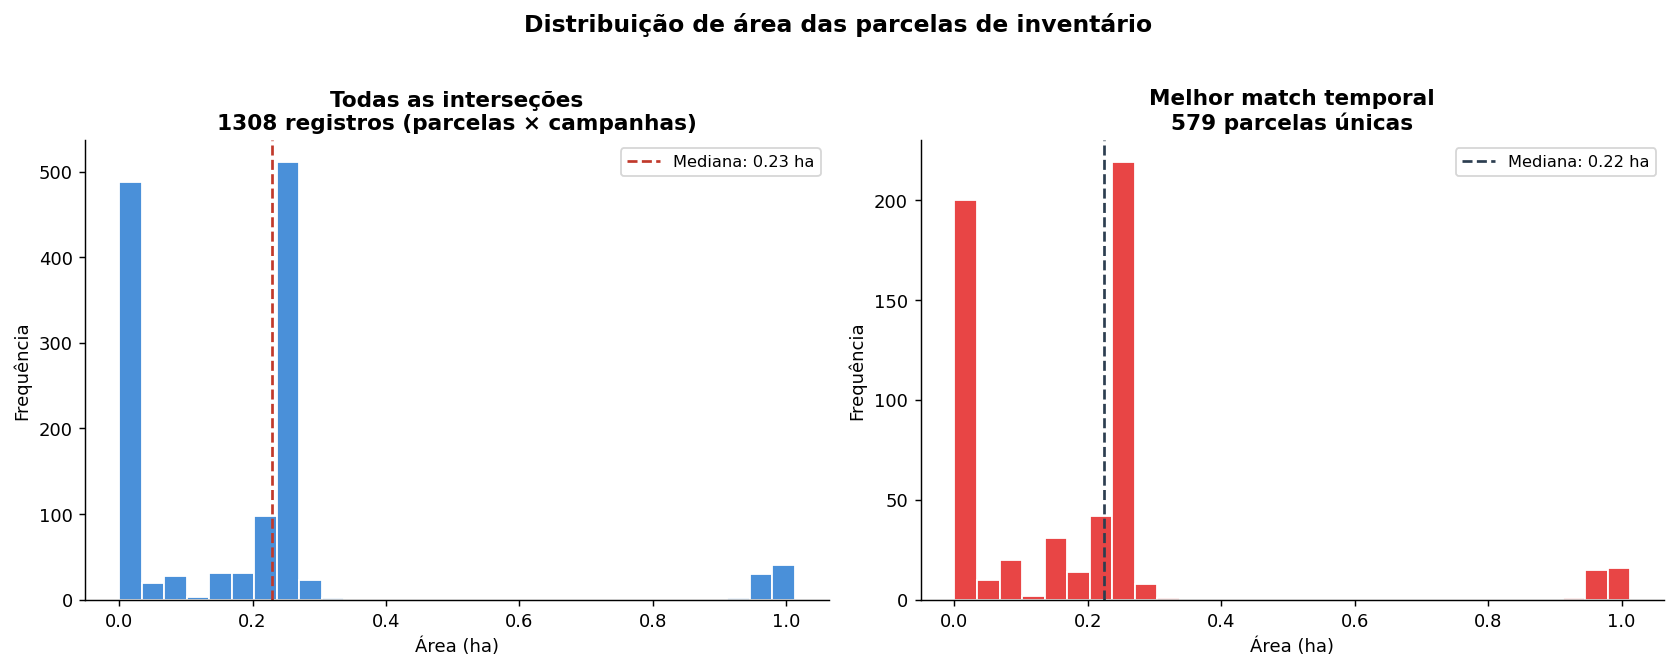


Área (ha) — todas as interseções:  min=0.00  mediana=0.23  max=1.01
Área (ha) — melhor match:           min=0.00  mediana=0.22  max=1.01


In [10]:
# Junta geometrias com os dois datasets (todas as interseções e melhor match)
all_pairs = (
    temp.drop_duplicates(["nome_area_inventario", "plot_id", "campanha_lidar"])
    .merge(plots_geo.rename(columns={"site": "nome_area_inventario"}),
           on=["nome_area_inventario", "plot_id"], how="inner")
)

best_plots = (
    best.merge(plots_geo.rename(columns={"site": "nome_area_inventario"}),
               on=["nome_area_inventario", "plot_id"], how="inner")
)

# --- Gráfico de área ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

axes[0].hist(all_pairs["area_ha"], bins=30, color="#4a90d9", edgecolor="white")
axes[0].axvline(all_pairs["area_ha"].median(), color="#c0392b", linestyle="--", linewidth=1.5,
                label=f"Mediana: {all_pairs['area_ha'].median():.2f} ha")
axes[0].set_xlabel("Área (ha)")
axes[0].set_ylabel("Frequência")
axes[0].set_title(
    f"Todas as interseções\n{len(all_pairs)} registros (parcelas × campanhas)",
    fontweight="bold"
)
axes[0].legend(fontsize=9)

axes[1].hist(best_plots["area_ha"], bins=30, color="#e84545", edgecolor="white")
axes[1].axvline(best_plots["area_ha"].median(), color="#2c3e50", linestyle="--", linewidth=1.5,
                label=f"Mediana: {best_plots['area_ha'].median():.2f} ha")
axes[1].set_xlabel("Área (ha)")
axes[1].set_ylabel("Frequência")
axes[1].set_title(
    f"Melhor match temporal\n{len(best_plots)} parcelas únicas",
    fontweight="bold"
)
axes[1].legend(fontsize=9)

plt.suptitle("Distribuição de área das parcelas de inventário", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"\nÁrea (ha) — todas as interseções:  min={all_pairs['area_ha'].min():.2f}  "
      f"mediana={all_pairs['area_ha'].median():.2f}  max={all_pairs['area_ha'].max():.2f}")
print(f"Área (ha) — melhor match:           min={best_plots['area_ha'].min():.2f}  "
      f"mediana={best_plots['area_ha'].median():.2f}  max={best_plots['area_ha'].max():.2f}")

---
## 5. Variabilidade de formato das parcelas

**Compacidade** (isoperimetric quotient): `4π × área / perímetro²`

- **1.0** = círculo perfeito
- **~0.79** = quadrado
- **< 0.5** = forma muito alongada ou irregular

Indica o quão "redondo" vs. "estranho" é o polígono de cada parcela.

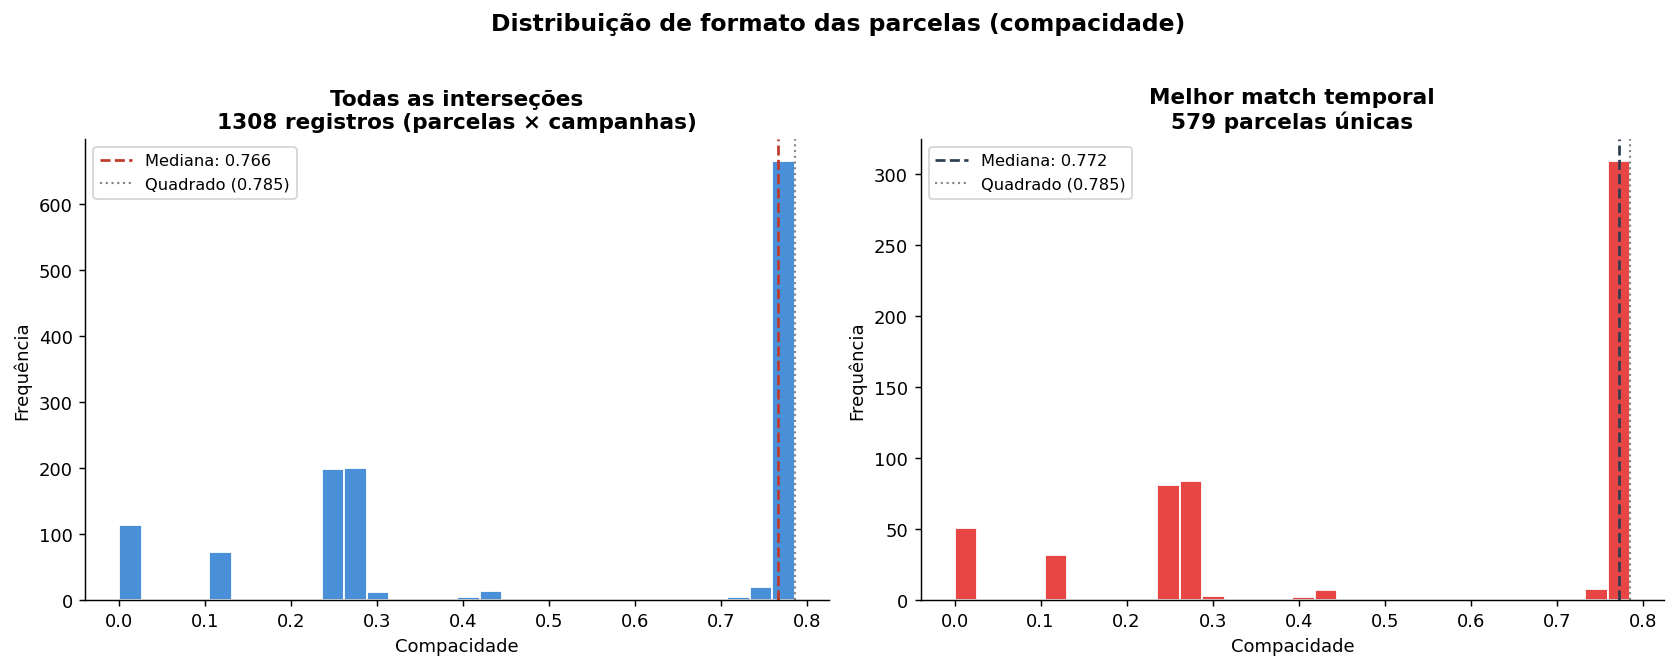

Parcelas mais irregulares (menor compacidade):
        nome_area_inventario plot_id  area_ha  compacidade
FNA_A01_2013_inventory_plots     T01      0.0          0.0
FNA_A01_2013_inventory_plots     T01      0.0          0.0
FNA_A01_2013_inventory_plots     T01      0.0          0.0
FNA_A01_2013_inventory_plots     T01      0.0          0.0
FNA_A01_2013_inventory_plots     T02      0.0          0.0

Parcelas mais compactas (maior compacidade):
       nome_area_inventario plot_id  area_ha  compacidade
CAU_A01_2014_2018_inventory     T10 0.249720     0.785366
CAU_A01_2014_2018_inventory     T10 0.249720     0.785365
CAU_A01_2014_2018_inventory     T10 0.249720     0.785365
CAU_A01_2014_2018_inventory     T21 0.249719     0.785365
CAU_A01_2014_2018_inventory     T21 0.249719     0.785365


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=False)

axes[0].hist(all_pairs["compacidade"], bins=30, color="#4a90d9", edgecolor="white")
axes[0].axvline(all_pairs["compacidade"].median(), color="#c0392b", linestyle="--", linewidth=1.5,
                label=f"Mediana: {all_pairs['compacidade'].median():.3f}")
axes[0].axvline(np.pi / 4, color="#888", linestyle=":", linewidth=1.2, label="Quadrado (0.785)")
axes[0].set_xlabel("Compacidade")
axes[0].set_ylabel("Frequência")
axes[0].set_title(
    f"Todas as interseções\n{len(all_pairs)} registros (parcelas × campanhas)",
    fontweight="bold"
)
axes[0].legend(fontsize=9)

axes[1].hist(best_plots["compacidade"], bins=30, color="#e84545", edgecolor="white")
axes[1].axvline(best_plots["compacidade"].median(), color="#2c3e50", linestyle="--", linewidth=1.5,
                label=f"Mediana: {best_plots['compacidade'].median():.3f}")
axes[1].axvline(np.pi / 4, color="#888", linestyle=":", linewidth=1.2, label="Quadrado (0.785)")
axes[1].set_xlabel("Compacidade")
axes[1].set_ylabel("Frequência")
axes[1].set_title(
    f"Melhor match temporal\n{len(best_plots)} parcelas únicas",
    fontweight="bold"
)
axes[1].legend(fontsize=9)

plt.suptitle("Distribuição de formato das parcelas (compacidade)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Exemplos dos extremos
print("Parcelas mais irregulares (menor compacidade):")
print(best_plots.nsmallest(5, "compacidade")[["nome_area_inventario", "plot_id", "area_ha", "compacidade"]].to_string(index=False))
print("\nParcelas mais compactas (maior compacidade):")
print(best_plots.nlargest(5, "compacidade")[["nome_area_inventario", "plot_id", "area_ha", "compacidade"]].to_string(index=False))